<a href="https://colab.research.google.com/github/lena29122005-creator/-/blob/main/%D0%98%D1%82%D0%B5%D1%80%D0%B0%D1%86%D0%B8%D1%8F_3_%D0%A1%D0%B5%D1%80%D0%B3%D0%B5%D0%B5%D0%B2%D0%B0_%D0%95_%D0%90_%D0%93%D1%80%D1%83%D0%BF%D0%BF%D0%B0_%D0%A1%D0%98%D0%98_25_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ссылка на датасет:
https://www.kaggle.com/datasets/dhrubangtalukdar/startup-funding-and-outcome-dataset

### **1) Загрузка и первичная обработка данных:**

In [118]:
# Загрузка датасета
import numpy as np
from google.colab import drive
drive.mount("/content/drive")
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Заочка/startup_success_dataset.csv")
# Подключение библеотеки для визуализации данных
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [119]:
# первые строки
df.head()

,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million,investor_type,sector,founder_background,outcome
0,4,13,58,48.225483,594843,18.519211,1.483962e+06,tier2_vc,Health,academic,IPO
1,1,6,221,31.532647,393020,14.298149,8.620568e+05,tier2_vc,Fintech,first_time,Failure
2,3,5,247,4.969722,27636,20.447567,9.726169e+04,none,SaaS,first_time,Failure
3,3,14,229,3.084209,235376,8.177417,1.145785e+06,none,Ecommerce,ex_bigtech,Acquisition
4,1,17,235,13.818188,391765,4.879792,8.608949e+05,none,Health,first_time,Acquisition


In [120]:
# последние строки
df.tail()

,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million,investor_type,sector,founder_background,outcome
99995,1,10,189,38.766348,261932,7.945616,1.005687e+06,tier1_vc,Ecommerce,serial_founder,Failure
99996,1,15,39,49.983039,355153,93.223490,1.627273e+06,none,AI,first_time,Acquisition
99997,0,22,215,3.086470,606292,12.832589,1.967245e+06,tier1_vc,Health,academic,Failure
99998,4,24,231,10.815435,277717,28.205609,2.757053e+05,angel,Crypto,ex_bigtech,Failure
99999,2,9,286,9.505618,227192,24.351561,1.018080e+06,tier1_vc,AI,first_time,Acquisition


In [121]:
# Размер (строк, столбцов)
df.shape

(100000, 11)

In [122]:
# Типы данных
df.dtypes

,0
funding_rounds,int64
founder_experience_years,int64
team_size,int64
market_size_billion,float64
product_traction_users,int64
burn_rate_million,float64
revenue_million,float64
investor_type,object
sector,object
founder_background,object


In [123]:
# Пропущенные значения:
df.isnull().sum()

,0
funding_rounds,0
founder_experience_years,0
team_size,0
market_size_billion,0
product_traction_users,0
burn_rate_million,0
revenue_million,0
investor_type,0
sector,0
founder_background,0


### **2) Очистка данных**

In [124]:
# Проверяем на наличие пропущенных значений и видим, что их нет в изначальной версии Датасета
df.isna().any()

,0
funding_rounds,False
founder_experience_years,False
team_size,False
market_size_billion,False
product_traction_users,False
burn_rate_million,False
revenue_million,False
investor_type,False
sector,False
founder_background,False


In [125]:
# Искусственное добавление пропусков
# Сохраняем оригинальный столбец для проверки
df_clean = df.copy()

print("Исходное количество пропусков в investor_type:", df_clean["investor_type"].isnull().sum())

# Добавляем пропуски: 10% случайных строк
# Выбираем 10% случайных индексов
sample_idx = df_clean.sample(frac=0.1, random_state=42).index
df_clean.loc[sample_idx, "investor_type"] = np.nan

print("Количество пропусков после искусственного добавления:", df_clean["investor_type"].isnull().sum())

# Заменяем пропуски в investor_type на "неизвестно"
df_clean["investor_type"] = df_clean["investor_type"].fillna("неизвестно")

print("Проверка: пропусков в investor_type после замены:", df_clean["investor_type"].isnull().sum())


Исходное количество пропусков в investor_type: 0
Количество пропусков после искусственного добавления: 10000
Проверка: пропусков в investor_type после замены: 0


In [126]:
# Количество полных дубликатов
print("Количество полных дубликатов:", df_clean.duplicated().sum())

Количество полных дубликатов: 0


### **3) Базовый анализ данных**

In [127]:
# Основные статистики по числовым столбцам
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns

print("Основные статистики по числовым столбцам:")
for col in numeric_cols:
    print(f"\n--- {col} ---")
    print("Среднее:", df_clean[col].mean())
    print("Медиана:", df_clean[col].median())
    print("Минимум:", df_clean[col].min())
    print("Максимум:", df_clean[col].max())
    print("Стандартное отклонение:", df_clean[col].std())

Основные статистики по числовым столбцам:

--- funding_rounds ---
Среднее: 2.0023
Медиана: 2.0
Минимум: 0
Максимум: 8
Стандартное отклонение: 1.4146712420026133

--- founder_experience_years ---
Среднее: 12.0243
Медиана: 12.0
Минимум: 0
Максимум: 24
Стандартное отклонение: 7.208089141755429

--- team_size ---
Среднее: 150.732
Медиана: 151.0
Минимум: 2
Максимум: 299
Стандартное отклонение: 86.27263068707316

--- market_size_billion ---
Среднее: 33.203875495867265
Медиана: 20.158062564727892
Минимум: 0.2887382859868989
Максимум: 1072.43447610433
Стандартное отклонение: 43.03475273783275

--- product_traction_users ---
Среднее: 285422.83273
Медиана: 264989.5
Минимум: 668
Максимум: 915203
Стандартное отклонение: 159323.8854049391

--- burn_rate_million ---
Среднее: 16.77621339820337
Медиана: 12.169059385872167
Минимум: 0.2797631616181472
Максимум: 357.491454344996
Стандартное отклонение: 15.711367781151731

--- revenue_million ---
Среднее: 782819.1436831742
Медиана: 621362.3894345223
Миним

In [128]:
# Баланс классов в целевом столбце "Раунды финансирования"
if "funding_rounds" in df_clean.columns:
    print("\nБаланс классов (funding_rounds):")
    print(df_clean["funding_rounds"].value_counts(normalize=True) * 100)


Баланс классов (funding_rounds):
funding_rounds
2    27.168
1    26.945
3    17.890
0    13.550
4     9.199
5     3.581
6     1.197
7     0.364
8     0.106
Name: proportion, dtype: float64


In [129]:
# Groupby: Средний опыт основателя в годах по раунду финансирования
if {"funding_rounds", "founder_experience_years"}.issubset(df_clean.columns):
    print("\nСредний опыт основателя в годах по раунду финансирования:")
    print(df_clean.groupby("funding_rounds")["founder_experience_years"].mean())

#Топ‑5 Секторов по количеству стартапов
print("\nТоп‑5 Секторов по количеству стартапов:", df_clean["sector"].value_counts().head(5))


Средний опыт основателя в годах по раунду финансирования:
funding_rounds
0    12.119852
1    11.961069
2    12.002908
3    12.050475
4    12.120774
5    11.892209
6    12.142022
7    12.434066
8    10.301887
Name: founder_experience_years, dtype: float64

Топ‑5 Секторов по количеству стартапов: sector
Crypto     14456
Climate    14412
Health     14357
SaaS       14333
Fintech    14220
Name: count, dtype: int64


**Вывод о наборе данных:**

Наиболее важными столбцами являются "funding_rounds" (количество раундов финансирования, привлеченных стартапом), "sector" (отраслевой сектор стартапа), "outcome" (итоговый результат: IPO, поглощение или банкротство). Они демонстрируют основые показатели уровня стартапа, его направленности, на что больше хочется обратить внимание при анализе датасета.

Основная закономерность в данном датасете — стартапы с большим суммарным финансированием чаще имеют статус «Acquired» или «IPO», чем закрытые. Стартапы, проходящие несколько раундов финансирования, чаще относятся к успешным исходам, чем «однораундовые».
Среди наиболее успешных по доле «Acquired» и суммарному финансированию часто выделяются IT‑сервисы, SaaS, платформы, финтех и маркетплейсы.

### **Библиотека matplotlib**



In [131]:
# Вместо df.dtypes посторим Линейчатую диаграмму

column_names = df.columns.tolist()
column_dtypes = df.dtypes.astype(str).tolist()
data = {
    'Столбцы': column_names,
    'Типы данных': column_dtypes,
}

df_ld = pd.DataFrame(data)
print(df_ld)

                     Столбцы Типы данных
0             funding_rounds       int64
1   founder_experience_years       int64
2                  team_size       int64
3        market_size_billion     float64
4     product_traction_users       int64
5          burn_rate_million     float64
6            revenue_million     float64
7              investor_type      object
8                     sector      object
9         founder_background      object
10                   outcome      object


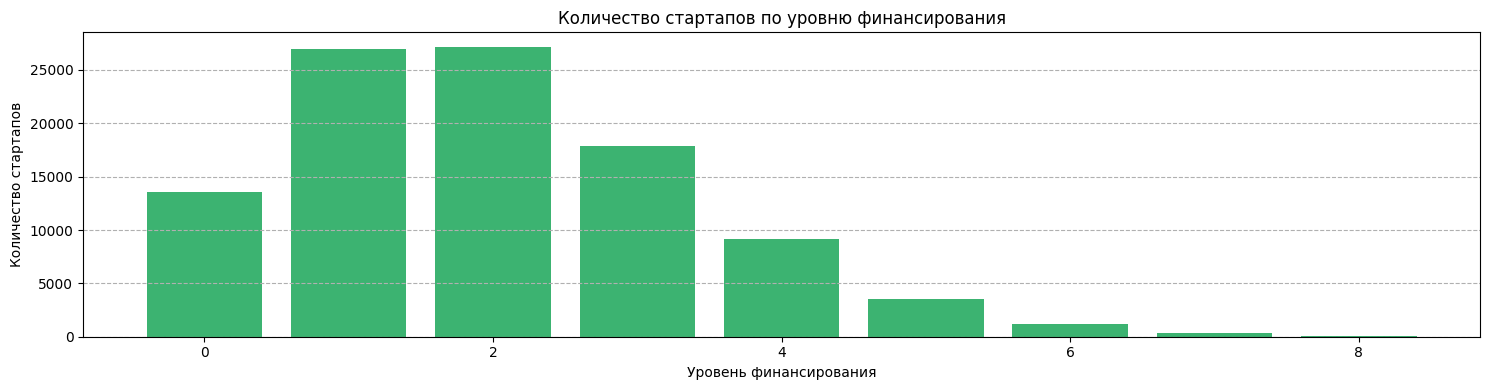

In [137]:
# Столбчатая диаграмма
fig, axs = plt.subplots(figsize=(15, 4))

counts = df['funding_rounds'].value_counts().sort_index()
axs.bar(counts.index, counts.values, color='mediumseagreen')
axs.set_title('Количество стартапов по уровню финансирования')
axs.set_xlabel('Уровень финансирования')
axs.set_ylabel('Количество стартапов')
axs.grid(axis='y', linestyle='--', alpha=1)

plt.tight_layout()
plt.show()

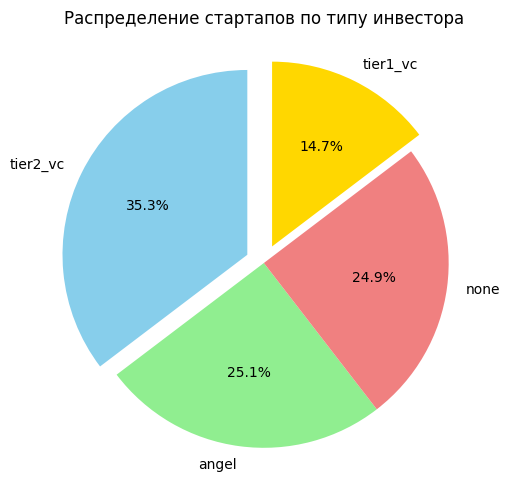

In [140]:
# Круговая диаграмма
counts = df['investor_type'].value_counts()
type_investor = counts.index.tolist()
count = counts.values.tolist()

explode = [0.1 if i in [0, 3] else 0 for i in range(len(count))]

plt.figure(figsize=(6, 6))
plt.pie(
    count,
    labels=type_investor,
    autopct='%1.1f%%',
    startangle=90,
    colors=['skyblue', 'lightgreen', 'lightcoral', 'gold', 'orchid'],
    explode=explode
)
plt.title('Распределение стартапов по типу инвестора')
plt.show()

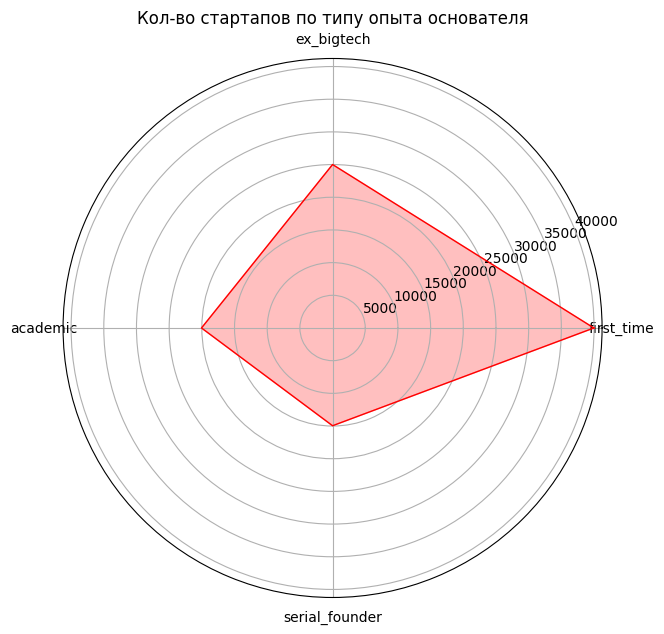

In [162]:
# Лепестковая диаграмма

counts = df['founder_background'].value_counts()
categories = counts.index.tolist()
values = counts.values.tolist()

angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
values += values[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.plot(angles, values, color='red', linewidth=1)
ax.fill(angles, values, color='r', alpha=0.25)
ax.set_thetagrids(np.degrees(angles[:-1]), categories)
plt.title('Кол-во стартапов по типу биографии основателя', y=1.05)
plt.show()